# 04. MLP con PINN como función de Pérdida utilizando Optuna

## 1. Introducción

## 2. Implementación

Primeramente se importan los módulos necesarios para la realización de esta
etapa.

In [1]:
# Se recarga el paquete src
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import optuna
import gc # Garbage Collector para evitar Out of Memory
import json
import os

# Se importan los módulos internos
from src.dataset.dataset import RadiationDataset
from src.learning.models import PINNEmbrittlement, pinn_loss

/home/lonelywolf/miniforge3/envs/tfm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Después se carga el Dataset y se preprocesa.

In [2]:
# 1. Instanciar Dataset
csv_path = '../data/df_plotter_cm2.csv'
dataset = RadiationDataset(csv_path)

# 2. División (80% Train+Val para búsqueda, 20% Test puro aislado)
train_val_set, _, test_set = dataset.data_split(test_factor=0.2)

# 3. Preprocesamiento (Ajustado solo en el Train)
dataset.preprocess(train_val_set, preprocessor=StandardScaler())

# 4. DataLoaders para la fase final
full_train_loader = DataLoader(train_val_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Dataset listo. Entrenamiento/Búsqueda: {len(train_val_set)} | Test: {len(test_set)}")

Dataset listo. Entrenamiento/Búsqueda: 1511 | Test: 378


Se crea objeto de la red neuronal y se buscan mejores hiperparámetros con
optuna.

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando en: {device}")

K_FOLDS = 5
kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
MAX_EPOCHS = 450
PATIENCE = 40 

def objective(trial):
    # --- ESPACIO DE BÚSQUEDA ---
    num_layers = trial.suggest_int("num_layers", 2, 3)
    hidden_dim = trial.suggest_categorical("hidden_dim", [48, 64, 96, 128])
    activation_name = trial.suggest_categorical("activation", ["SiLU", "GELU"])
    lr = trial.suggest_float("learning_rate", 8e-4, 4e-3, log=True)
    lambda_mono = trial.suggest_float("lambda_mono", 0.05, 1.2)
    weight_decay = trial.suggest_float("weight_decay", 5e-5, 2e-3, log=True)
    
    activations = {"SiLU": nn.SiLU, "GELU": nn.GELU}
    
    fold_best_val_losses = []
    fold_best_epochs = []
    dataset_indices = list(range(len(train_val_set)))
    
    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset_indices)):
        train_sub = Subset(train_val_set, train_ids)
        val_sub = Subset(train_val_set, val_ids)
        train_loader_fold = DataLoader(train_sub, batch_size=32, shuffle=True)
        val_loader_fold = DataLoader(val_sub, batch_size=32, shuffle=False)
        
        model = PINNEmbrittlement(
            input_dim=7, hidden_dim=hidden_dim, num_layers=num_layers,
            activation=activations[activation_name], preprocessor=dataset.preprocessor
        ).to(device)
        
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        best_epoch = 0
        
        for epoch in range(MAX_EPOCHS):
            # Train
            model.train()
            for batch in train_loader_fold:
                batch = batch.to(device)
                X_batch = torch.cat([batch[:, :6], batch[:, 7:]], dim=1)
                y_batch = batch[:, 6].view(-1, 1)
                
                X_batch.requires_grad_(True)
                optimizer.zero_grad()
                loss, _, _ = pinn_loss(model, X_batch, y_batch, fluence_idx=6, lambda_data=1.0, lambda_mono=lambda_mono)
                loss.backward()
                optimizer.step()
                
            # Val
            model.eval()
            val_loss_total = 0.0
            with torch.no_grad():
                for batch in val_loader_fold:
                    batch = batch.to(device)
                    X_batch = torch.cat([batch[:, :6], batch[:, 7:]], dim=1)
                    y_batch = batch[:, 6].view(-1, 1)
                    preds = model(X_batch)
                    val_loss_total += nn.functional.mse_loss(preds, y_batch).item()
            
            current_val_loss = val_loss_total / len(val_loader_fold)
            
            # Early Stopping
            if current_val_loss < best_val_loss:
                best_val_loss = current_val_loss
                best_epoch = epoch
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if epochs_no_improve >= PATIENCE:
                break
                
        fold_best_val_losses.append(best_val_loss)
        fold_best_epochs.append(best_epoch)
        
        # --- ANTI OUT-OF-MEMORY (Limpieza profunda) ---
        del model
        del optimizer
        del train_loader_fold
        del val_loader_fold
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
    avg_best_epoch = int(np.mean(fold_best_epochs))
    trial.set_user_attr("optimal_epochs", avg_best_epoch)
    return np.mean(fold_best_val_losses)

print("Iniciando Optuna. Se guardará progreso en 'pinn_estudio.db'...")
# Configuramos la base de datos SQLite para que puedas pausar y reanudar sin perder nada
study = optuna.create_study(
    study_name="optimizacion_pinn", 
    storage="sqlite:///pinn_estudio.db", 
    load_if_exists=True,
    direction="minimize"
)

# N_TRIALS ALTO (Déjalo trabajar)
study.optimize(objective, n_trials=200) 

print("\n--- BÚSQUEDA FINALIZADA ---")
best_params = study.best_params
print("Mejores parámetros:", best_params)
best_epoch_found = study.best_trial.user_attrs["optimal_epochs"]

# Compensación: Como el modelo final usa el 100% de los datos (no solo un fold),
# necesita un ~15% más de épocas para converger.
final_epochs = int(best_epoch_found * 1.15) 
print(f"Épocas óptimas calibradas para el modelo final: {final_epochs}")

# 1. Crear la carpeta si no existe
results_path = "../results/04/"
os.makedirs(results_path, exist_ok=True)

# 2. Preparar el diccionario con toda la información relevante
best_data = {
    "trial_number": study.best_trial.number,
    "best_rmse_val": float(study.best_value), # El error medio del K-Fold
    "hiperparametros": study.best_params,
    "optimal_epochs_val": study.best_trial.user_attrs["optimal_epochs"],
    "final_epochs_calibrated": final_epochs, # Las que usaremos en el modelo final
    "datetime": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}

# 3. Guardar en un archivo JSON
file_name = os.path.join(results_path, "best_parameters.json")
with open(file_name, "w") as f:
    json.dump(best_data, f, indent=4)
study.trials_dataframe().to_csv(os.path.join(results_path, "full_optuna_history.csv"), index=False)

print(f"✅ ¡Éxito! Los mejores parámetros se han guardado en: {file_name}")

Ejecutando en: cuda
Iniciando Optuna. Se guardará progreso en 'pinn_estudio.db'...


[I 2026-02-28 11:16:32,117] Using an existing study with name 'optimizacion_pinn' instead of creating a new one.
[I 2026-02-28 11:18:36,351] Trial 3 finished with value: 0.1296891708672047 and parameters: {'num_layers': 3, 'hidden_dim': 64, 'activation': 'SiLU', 'learning_rate': 0.0034485837349005374, 'lambda_mono': 0.35546443160331653, 'weight_decay': 0.00013365546583606703}. Best is trial 3 with value: 0.1296891708672047.
[I 2026-02-28 11:21:46,297] Trial 4 finished with value: 0.14331059366464616 and parameters: {'num_layers': 2, 'hidden_dim': 64, 'activation': 'GELU', 'learning_rate': 0.001191732815303609, 'lambda_mono': 0.5074065905745597, 'weight_decay': 0.0010627137170340494}. Best is trial 3 with value: 0.1296891708672047.
[I 2026-02-28 11:23:33,226] Trial 5 finished with value: 0.1449301029741764 and parameters: {'num_layers': 2, 'hidden_dim': 96, 'activation': 'SiLU', 'learning_rate': 0.0026209351614796934, 'lambda_mono': 0.15719880645044484, 'weight_decay': 0.000210230060292


--- BÚSQUEDA FINALIZADA ---
Mejores parámetros: {'num_layers': 3, 'hidden_dim': 96, 'activation': 'GELU', 'learning_rate': 0.0029549607810257224, 'lambda_mono': 0.36408455929105954, 'weight_decay': 7.010115160487686e-05}
Épocas óptimas calibradas para el modelo final: 57
✅ ¡Éxito! Los mejores parámetros se han guardado en: ../results/04/best_parameters.json


In [4]:
activations = {"SiLU": nn.SiLU, "GELU": nn.GELU, "Tanh": nn.Tanh}

# Instanciamos el modelo campeón
modelo_campeon = PINNEmbrittlement(
    input_dim=7, hidden_dim=best_params["hidden_dim"], num_layers=best_params["num_layers"],
    activation=activations[best_params["activation"]], preprocessor=dataset.preprocessor
).to(device)

optimizer = optim.Adam(modelo_campeon.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

print(f"\nEntrenando modelo DEFINITIVO con el 100% de la data de entrenamiento por {final_epochs} épocas...")
for epoch in range(final_epochs):
    modelo_campeon.train()
    epoch_loss_data = 0.0
    epoch_loss_mono = 0.0
    
    for batch in full_train_loader:
        batch = batch.to(device)
        target_idx = 6
        X_batch = torch.cat([batch[:, :target_idx], batch[:, target_idx+1:]], dim=1)
        y_batch = batch[:, target_idx].view(-1, 1)
        
        X_batch.requires_grad_(True)
        optimizer.zero_grad()
        loss, loss_data, loss_mono = pinn_loss(
            modelo_campeon, X_batch, y_batch, fluence_idx=6, 
            lambda_data=1.0, lambda_mono=best_params["lambda_mono"]
        )
        loss.backward()
        optimizer.step()
        
        epoch_loss_data += loss_data.item()
        epoch_loss_mono += loss_mono.item()
        
    if (epoch+1) % 50 == 0 or (epoch+1) == final_epochs:
        print(f"Epoch {epoch+1:03d}/{final_epochs} | Loss MSE: {epoch_loss_data/len(full_train_loader):.4f} | Loss PINN: {epoch_loss_mono/len(full_train_loader):.4f}")

print("Entrenamiento campeón finalizado con éxito.")


Entrenando modelo DEFINITIVO con el 100% de la data de entrenamiento por 57 épocas...
Epoch 050/57 | Loss MSE: 0.0854 | Loss PINN: 0.0000
Epoch 057/57 | Loss MSE: 0.0829 | Loss PINN: 0.0001
Entrenamiento campeón finalizado con éxito.


Rendimiento Real del Modelo Campeón -> R²: 0.870 | RMSE: 13.019 °C


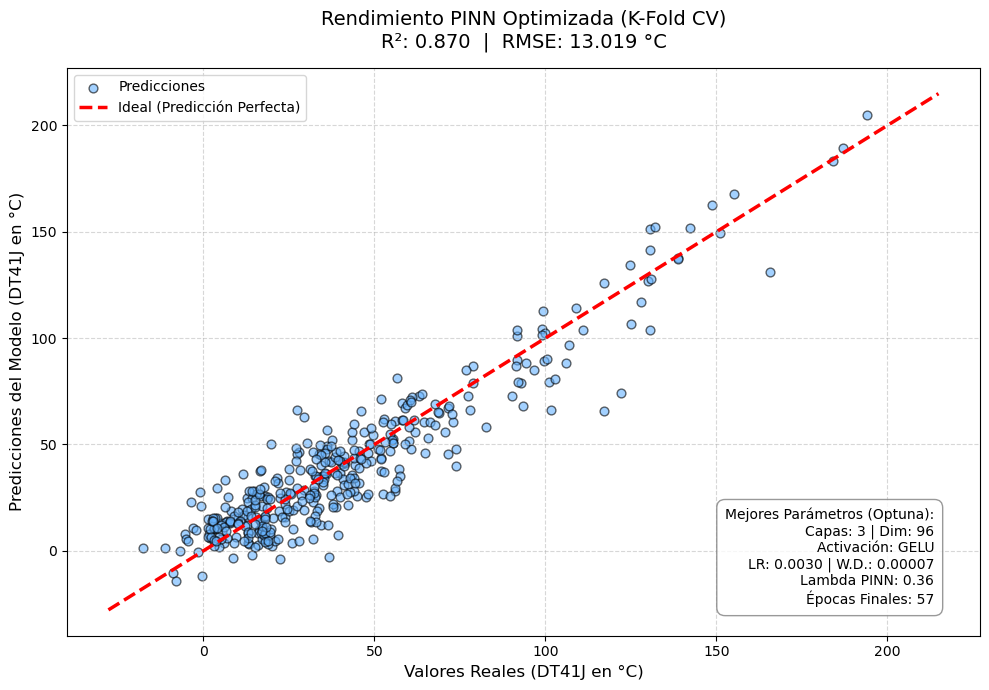

In [5]:
# 1. Modo evaluación
modelo_campeon.eval()
y_true_scaled = []
y_pred_scaled = []

# 2. Generar predicciones sobre Test (El conjunto que nunca vio)
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        target_idx = 6
        X_batch = torch.cat([batch[:, :target_idx], batch[:, target_idx+1:]], dim=1)
        y_batch = batch[:, target_idx].view(-1, 1)
        
        preds = modelo_campeon(X_batch)
        y_pred_scaled.append(preds.cpu().numpy())
        y_true_scaled.append(y_batch.cpu().numpy())

y_true_scaled = np.vstack(y_true_scaled)
y_pred_scaled = np.vstack(y_pred_scaled)

# 3. Desescalado de variables para leer en °C
num_columns = 8
dummy_true = np.zeros((len(y_true_scaled), num_columns))
dummy_pred = np.zeros((len(y_pred_scaled), num_columns))

dummy_true[:, target_idx] = y_true_scaled.flatten()
dummy_pred[:, target_idx] = y_pred_scaled.flatten()

y_true_unscaled = dataset.preprocessor.inverse_transform(dummy_true)[:, target_idx]
y_pred_unscaled = dataset.preprocessor.inverse_transform(dummy_pred)[:, target_idx]

# 4. Cálculo de métricas finales
r2 = r2_score(y_true_unscaled, y_pred_unscaled)
rmse = np.sqrt(mean_squared_error(y_true_unscaled, y_pred_unscaled))
print(f"Rendimiento Real del Modelo Campeón -> R²: {r2:.3f} | RMSE: {rmse:.3f} °C")

# --- GRÁFICA ---
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(y_true_unscaled, y_pred_unscaled, alpha=0.6, edgecolors='k', color='#66b3ff', s=40, label='Predicciones')

min_val = min(y_true_unscaled.min(), y_pred_unscaled.min()) - 10
max_val = max(y_true_unscaled.max(), y_pred_unscaled.max()) + 10
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Ideal (Predicción Perfecta)')

ax.set_xlabel('Valores Reales (DT41J en °C)', fontsize=12)
ax.set_ylabel('Predicciones del Modelo (DT41J en °C)', fontsize=12)
ax.set_title(f'Rendimiento PINN Optimizada (K-Fold CV)\nR²: {r2:.3f}  |  RMSE: {rmse:.3f} °C', fontsize=14, pad=15)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=10)

# Caja de texto automatizada
textstr = '\n'.join((
    r'Mejores Parámetros (Optuna):',
    f'Capas: {best_params["num_layers"]} | Dim: {best_params["hidden_dim"]}',
    f'Activación: {best_params["activation"]}',
    f'LR: {best_params["learning_rate"]:.4f} | W.D.: {best_params["weight_decay"]:.5f}',
    f'Lambda PINN: {best_params["lambda_mono"]:.2f}',
    f'Épocas Finales: {final_epochs}'
))

props = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.8)
ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.show()